In [1]:
# Imports
import gymnasium
from gymnasium import spaces
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Stock Trading Environment

In [ ]:
# Defining the Stock Trading Environment.

class StockTradingEnvironment(gymnasium.Env):
    """This class implements the Stock Trading environment."""

    def __init__(self, file_path, train=True, number_of_days_to_consider=10):
        """This method initializes the environment.

        :param file_path: - Path of the CSV file containing the historical stock data.
        :param train: - Boolean indicating whether the goal is to train or test the performance of the agent.
        :param number_of_days_to_consider = Integer representing the number of days the for which the agent
                considers the trend in stock price to make a decision."""

        self.file_path = file_path
        self.stock_data = pd.read_csv(self.file_path)
        self.train = train

        # Splitting the data into train and test datasets.
        self.training_stock_data = self.stock_data.iloc[:int(0.8 * len(self.stock_data))]
        self.testing_stock_data = self.stock_data.iloc[int(0.8 * len(self.stock_data)):].reset_index()

        self.observation_space = spaces.Discrete(4)
        self.action_space = spaces.Discrete(3)

        self.investment_capital = 100000  # This defines the investment capital that the agent starts with.
        self.number_of_shares = 0  # This defines number of shares currently held by the agent.
        self.stock_value = 0  # This defines the value of the stock currently held by the agent.
        self.book_value = 0  # This defines the total value for which the agent bought the shares.
        # This defines the agent's total account value.
        self.total_account_value = self.investment_capital + self.stock_value
        # List to store the total account value over training or evaluation.
        self.total_account_value_list = []
        # This defines the number of days for which the agent considers the data before taking an action.
        self.number_of_days_to_consider = number_of_days_to_consider
        # The maximum timesteps the agent will take before the episode ends.
        if self.train:
            self.max_timesteps = len(self.training_stock_data) - self.number_of_days_to_consider
        else:
            self.max_timesteps = len(self.testing_stock_data) - self.number_of_days_to_consider
        # Initializing the number of steps taken to 0.
        self.timestep = 0
        self.reset()

    def reset(self):
        """This method resets the environment and returns the observation.

        :returns observation: - Integer in the range of 0 to 3 representing the four possible observations that the
                                agent can receive. The observation depends upon whether the price increased on average
                                in the number of days the agent considers, and whether the agent already has the stock
                                or not.

         info: - A dictionary that can be used to provide additional implementation information."""

        self.investment_capital = 100000  # This defines the investment capital that the agent starts with.
        self.number_of_shares = 0  # This defines number of shares currently held by the agent.
        self.stock_value = 0  # This defines the value of the stock currently held by the agent.
        self.book_value = 0  # This defines the total value for which the agent bought the shares.
        # This defines the agent's total account value.
        self.total_account_value = self.investment_capital + self.stock_value
        # List to store the total account value over training or evaluation.
        self.total_account_value_list = []
        # Initializing the number of steps taken to 0.
        self.timestep = 0

        # Getting the observation vector.
        if self.train:
            # If the task is to train the agent the maximum timesteps will be equal to the number of days considered
            # subtracted from the  length of the training stock data.
            self.max_timesteps = len(self.training_stock_data) - self.number_of_days_to_consider

            # Calculating whether the price increased or decreased/remained the same on the majority of days the agent
            # considers.
            price_increase_list = []
            for i in range(self.number_of_days_to_consider):
                if self.training_stock_data['Close'][self.timestep + 1 + i] \
                        - self.training_stock_data['Close'][self.timestep + i] > 0:
                    price_increase_list.append(1)
                else:
                    price_increase_list.append(0)

            if (np.sum(price_increase_list) / self.number_of_days_to_consider) >= 0.5:
                price_increase = True
            else:
                price_increase = False

            stock_held = False

            # Observation vector that will be passed to the agent.
            observation = [price_increase, stock_held]

        else:
            # If the task is to evaluate the trained agent's performance the maximum timesteps will be equal to the
            # number of days considered subtracted from the  length of the testing stock data.
            self.max_timesteps = len(self.testing_stock_data) - self.number_of_days_to_consider

            # Calculating whether the price increased or decreased/remained the same on the majority of days the agent
            # considers.
            price_increase_list = []
            for i in range(self.number_of_days_to_consider):
                if self.testing_stock_data['Close'][self.timestep + 1 + i] \
                        - self.testing_stock_data['Close'][self.timestep + i] > 0:
                    price_increase_list.append(1)
                else:
                    price_increase_list.append(0)

            if (np.sum(price_increase_list) / self.number_of_days_to_consider) >= 0.5:
                price_increase = True
            else:
                price_increase = False

            stock_held = False

            # Observation vector.
            observation = [price_increase, stock_held]

        if np.array_equal(observation, [True, False]):
            observation = 0
        if np.array_equal(observation, [True, True]):
            observation = 1
        if np.array_equal(observation, [False, False]):
            observation = 2
        if np.array_equal(observation, [False, True]):
            observation = 3

        info = None

        return observation, info

    def step(self, action):
        """This method implements what happens when the agent takes the action to Buy/Sell/Hold.

        :param action: - Integer in the range 0 to 2 inclusive.

        :returns observation: - Integer in the range of 0 to 3 representing the four possible observations that the
                                agent can receive. The observation depends upon whether the price increased on average
                                in the number of days the agent considers, and whether the agent already has the stock
                                or not.
                 reward: - Integer/Float value that's used to measure the performance of the agent.
                 terminated: - Boolean describing whether the episode has terminated.
                 truncated: - Boolean describing whether a truncation condition outside the scope of the MDP is satisfied.
                 info: - A dictionary that can be used to provide additional implementation information."""

        # We give the agent a penalty for taking actions such as buying a stock when the agent doesn't have the
        # investment capital and selling a stock when the agent doesn't have any shares.
        penalty = 0

        if self.train:
            if action == 0:  # Buy
                if self.number_of_shares > 0:
                    penalty = -10
                # Determining the number of shares the agent can buy.
                number_of_shares_to_buy = math.floor(self.investment_capital / self.training_stock_data[
                    'Open'][self.timestep + self.number_of_days_to_consider])
                # Adding to the number of shares the agent has.
                self.number_of_shares += number_of_shares_to_buy

                # Computing the stock value, book value, investment capital and reward.
                if number_of_shares_to_buy > 0:
                    self.stock_value +=\
                        self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                        * number_of_shares_to_buy
                    self.book_value += \
                        self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider]\
                        * number_of_shares_to_buy
                    self.investment_capital -= \
                        self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                        * number_of_shares_to_buy

                    reward = 1 + penalty

                else:
                    # Computing the stock value and reward.
                    self.stock_value = \
                        self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                        * self.number_of_shares
                    reward = -10

            if action == 1:  # Sell
                # Computing the investment capital, sell value and reward.
                self.investment_capital += \
                    self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                    * self.number_of_shares
                sell_value = self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                             * self.number_of_shares

                if self.book_value > 0:
                    reward = (sell_value - self.book_value) / self.book_value * 100
                else:
                    reward = -10

                self.number_of_shares = 0
                self.stock_value = 0
                self.book_value = 0

            if action == 2:  # Hold
                # Computing the stock value and reward.
                self.stock_value = self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                                   * self.number_of_shares

                if self.book_value > 0:
                    reward = (self.stock_value - self.book_value) / self.book_value * 100
                else:
                    reward = -1

        else:
            if action == 0:  # Buy
                if self.number_of_shares > 0:
                    penalty = -10
                # Determining the number of shares the agent can buy.
                number_of_shares_to_buy = math.floor(self.investment_capital / self.testing_stock_data[
                    'Open'][self.timestep + self.number_of_days_to_consider])
                # Adding to the number of shares the agent has.
                self.number_of_shares += number_of_shares_to_buy

                # Computing the stock value, book value, investment capital and reward.
                if number_of_shares_to_buy > 0:
                    self.stock_value += \
                        self.testing_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                        * number_of_shares_to_buy
                    self.book_value += \
                        self.testing_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                        * number_of_shares_to_buy
                    self.investment_capital -= \
                        self.testing_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                        * number_of_shares_to_buy

                    reward = 1 + penalty

                else:
                    # Computing the stock value and reward.
                    self.stock_value = self.training_stock_data['Open'][
                                           self.timestep + self.number_of_days_to_consider] * self.number_of_shares
                    reward = -10

            if action == 1:  # Sell
                # Computing the investment capital, sell value and reward.
                self.investment_capital += \
                    self.testing_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                    * self.number_of_shares
                sell_value = self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                             * self.number_of_shares

                if self.book_value > 0:
                    reward = (sell_value - self.book_value) / self.book_value * 100
                else:
                    reward = -10

                self.number_of_shares = 0
                self.stock_value = 0
                self.book_value = 0

            if action == 2:  # Hold
                # Computing the stock value and reward.
                self.stock_value = self.testing_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                                   * self.number_of_shares

                if self.book_value > 0:
                    reward = (self.stock_value - self.book_value) / self.book_value * 100
                else:
                    reward = -1

        # Determining if the agent currently has shares of the stock or not.
        if self.number_of_shares > 0:
            stock_held = True
        else:
            stock_held = False

        # Getting the observation vector.
        if self.train:
            # If the task is to train the agent the maximum timesteps will be equal to the number of days considered
            # subtracted from the  length of the training stock data.
            self.max_timesteps = len(self.training_stock_data) - self.number_of_days_to_consider

            # Calculating whether the price increased or decreased/remained the same on the majority of days the agent
            # considers.
            price_increase_list = []
            for i in range(self.number_of_days_to_consider):
                if self.training_stock_data['Close'][self.timestep + 1 + i] \
                        - self.training_stock_data['Close'][self.timestep + i] > 0:
                    price_increase_list.append(1)
                else:
                    price_increase_list.append(0)

            if (np.sum(price_increase_list) / self.number_of_days_to_consider) >= 0.5:
                price_increase = True
            else:
                price_increase = False

            # Observation vector.
            observation = [price_increase, stock_held]

        else:
            # If the task is to evaluate the trained agent's performance the maximum timesteps will be equal to the
            # number of days considered subtracted from the  length of the testing stock data.
            self.max_timesteps = len(self.testing_stock_data) - self.number_of_days_to_consider

            # Calculating whether the price increased or decreased/remained the same on the majority of days the agent
            # considers.
            price_increase_list = []
            for i in range(self.number_of_days_to_consider):
                if self.testing_stock_data['Close'][self.timestep + 1 + i] \
                        - self.testing_stock_data['Close'][self.timestep + i] > 0:
                    price_increase_list.append(1)
                else:
                    price_increase_list.append(0)

            if (np.sum(price_increase_list) / self.number_of_days_to_consider) >= 0.5:
                price_increase = True
            else:
                price_increase = False

            # Observation vector.
            observation = [price_increase, stock_held]

        self.timestep += 1  # Increasing the number of steps taken by the agent by 1.

        if np.array_equal(observation, [True, False]):
            observation = 0
        if np.array_equal(observation, [True, True]):
            observation = 1
        if np.array_equal(observation, [False, False]):
            observation = 2
        if np.array_equal(observation, [False, True]):
            observation = 3

        # Computing the total account value.
        self.total_account_value = self.investment_capital + self.stock_value
        # Appending the total account value of the list to plot the graph.
        self.total_account_value_list.append(self.total_account_value)

        # The episode terminates when the maximum timesteps have been reached.
        terminated = True if (self.timestep >= self.max_timesteps) \
            else False
        truncated = False
        info = {}

        return observation, reward, terminated, truncated, info

    def render(self, mode='human'):
        """This method renders the agent's total account value over time.

        :param mode: 'human' renders to the current display or terminal and returns nothing."""

        plt.figure(figsize=(15, 10))
        plt.plot(self.total_account_value_list, color='lightseagreen', linewidth=7)
        plt.xlabel('Days', fontsize=32)
        plt.ylabel('Total Account Value', fontsize=32)
        plt.title('Total Account Value over Time', fontsize=38)
        plt.grid()
        plt.show()

In [4]:
# NOTE: You can adjust the parameter 'number_of_days_to_consider'. To train the agent, set 'train=True', and to evaluate the agent, set 'train=False'.

stock_trading_environment = StockTradingEnvironment(file_path='./NVDA.csv', train=True, number_of_days_to_consider=10)

In [ ]:
# def env_mapping_dict():
#   dict1 = {}
#   index = 0
#   for price in [0, 1]:
#       for held in [0, 1]:
#           dict1[(price, held)] = index
#           index += 1
#   print(dict1)
# env_mapping_dict()

### TO DO: Implement the Q-learning algorithm

In [7]:
# Q-Learning:
def train_q_learning(env, number_of_episodes=500, alpha=0.1, gamma=0.7, epsilon=0.99, decay=0.998):

    # Get number of states and actions from environment
    number_of_state = env.observation_space.n
    number_of_actions = env.action_space.n

    q_table = np.zeros((number_of_state, number_of_actions))
    print(q_table.shape)
    q_learning_reward_list = []
    q_learning_epsilon_list = []


    for ep in range(number_of_episodes):

        # We always reset env at the start of every episode!!! This is because agent completes one learning step of pick and delivering the package.
        obs, info = env.reset()
        # state = state_dict_mapping() # Delete this(old q-learning mapping logic).
        # print(obs)
        state = obs
        q_learning_total_reward = 0
        # We need to iterate till max steps:
        # Then leverage the epsilon greedy approach and pick a random action or the best action.
        # We pass this action to our env step function we created before and get 4/5 things in return like last time.
        # for i in range(max_timesteps)
        for t_step in range(env.max_timesteps):

            # explore if random < epsilon
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                # exploit case
                action = np.argmax(q_table[state, :])

            # Get the next observation, action, reward details! But dont update that as the final next action yet as we need to check in Q-Table frist!!!!
            # obs, r, term, trunc, info
            obs, reward, term, trunc, info = env.step(action)
            # Getting the next state and storing it inside a temp variable for now as we will need it in formula!!
            next_state = obs


            # Calculation of the Q-table
            target = reward + gamma * np.max(q_table[next_state, :])
            q_table[state, action] += alpha * (target - q_table[state, action])

            # Now finally update the staet!!
            state = next_state
            q_learning_total_reward += reward



            if term or trunc:
                break

        q_learning_reward_list.append(q_learning_total_reward)
        q_learning_epsilon_list.append(epsilon)
        # Decay epsilon
        epsilon *= decay
        # if epsilon < 0.05:
        #     epsilon = 0.05

        if ep % 50 == 0:
            print(f"TREND:{next_state} | ACTION: {action}")
            print(f"Episode {ep}, Total Acc. Value:{env.total_account_value:.2f} Total reward: {q_learning_total_reward}, Epsilon: {epsilon:.2f}")
            # env.render()
    # print(env.state_to_index_map)
    return q_table, q_learning_reward_list, q_learning_epsilon_list


In [8]:

stock_trading_environment = StockTradingEnvironment(file_path='./NVDA.csv', train=True, number_of_days_to_consider=10)
q_table, q_learning_reward_list, q_learning_epsilon_list = train_q_learning(stock_trading_environment, number_of_episodes=1000, alpha=0.1, gamma=0.7, epsilon=0.99)


(4, 3)
TREND:3 | ACTION: 2
Episode 0, Total Acc. Value:174657.63 Total reward: -1244.5625500415924, Epsilon: 0.99
TREND:2 | ACTION: 2
Episode 50, Total Acc. Value:382457.12 Total reward: -767.2347821050702, Epsilon: 0.89
TREND:3 | ACTION: 0
Episode 100, Total Acc. Value:249269.47 Total reward: -1104.730360837045, Epsilon: 0.81
TREND:2 | ACTION: 2
Episode 150, Total Acc. Value:337383.26 Total reward: -847.2752764544065, Epsilon: 0.73
TREND:2 | ACTION: 1
Episode 200, Total Acc. Value:353862.90 Total reward: -365.0992952135787, Epsilon: 0.66
TREND:2 | ACTION: 2
Episode 250, Total Acc. Value:468432.43 Total reward: -70.95155257685941, Epsilon: 0.60
TREND:3 | ACTION: 0
Episode 300, Total Acc. Value:211323.46 Total reward: -293.25673684133244, Epsilon: 0.54
TREND:2 | ACTION: 1
Episode 350, Total Acc. Value:261948.02 Total reward: 282.4908936658004, Epsilon: 0.49
TREND:3 | ACTION: 0
Episode 400, Total Acc. Value:361027.77 Total reward: 341.8644683240468, Epsilon: 0.44
TREND:3 | ACTION: 0
Epis

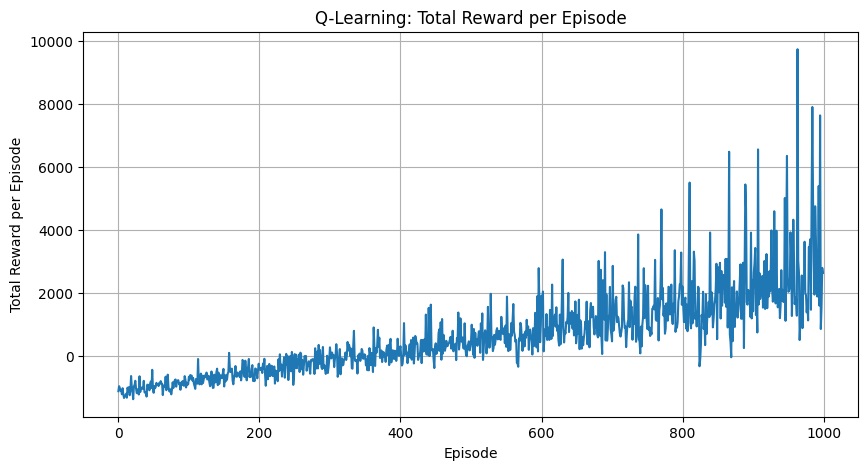

In [ ]:
# Q- Learning: Base Case plot
def reward_plot(q_learning_reward_list):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))
    plt.plot(q_learning_reward_list)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward per Episode")
    plt.title("Q-Learning: Total Reward per Episode")
    plt.grid()
    plt.show()

reward_plot(q_learning_reward_list)


Episode finished after 95 steps
Total reward: 1983.7654
Final account value: 129865.50
STEP 94 | ACTION: 2 | REWARD: 29.8746 | STATE: 3


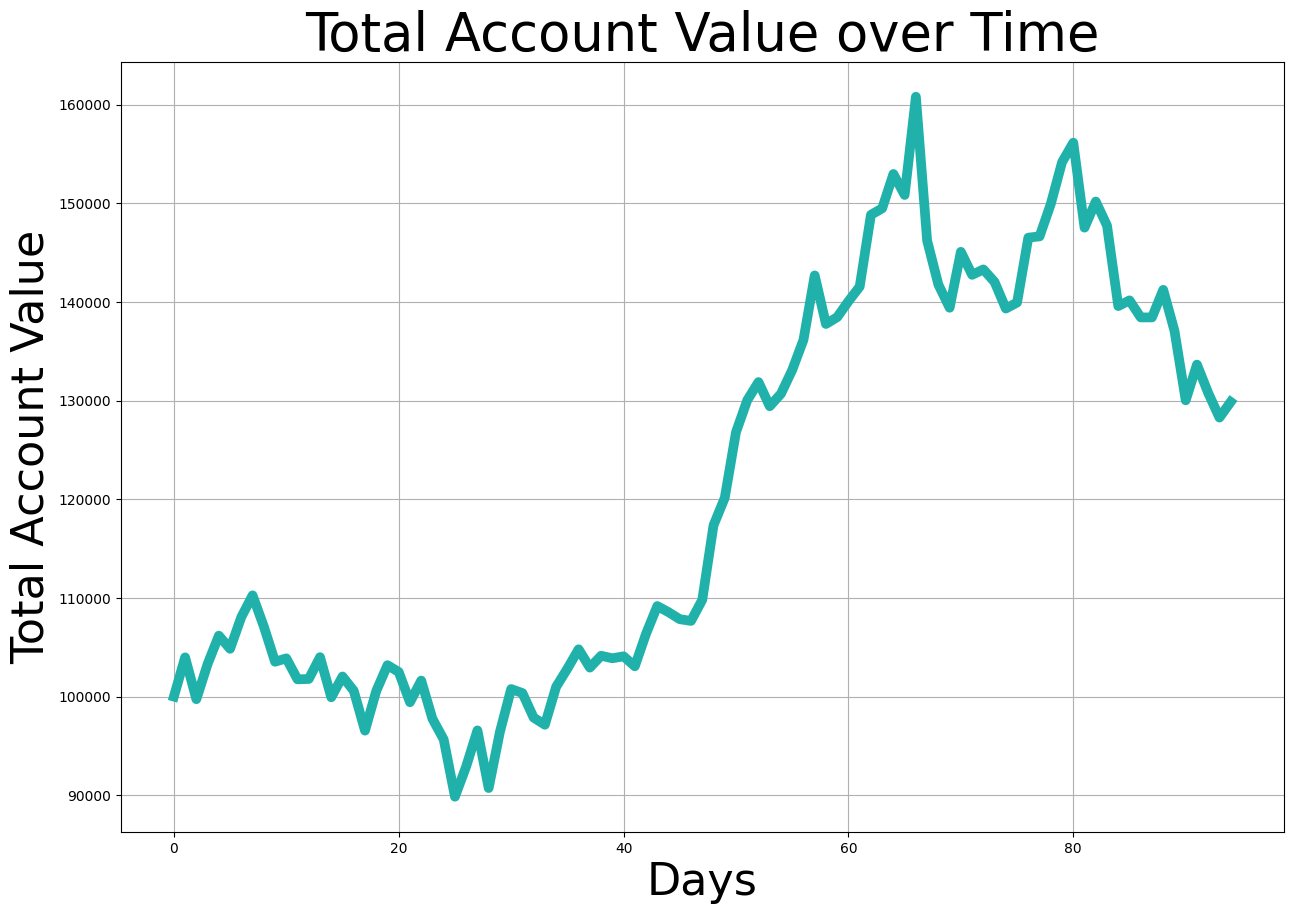

In [ ]:
def run_trained_q_learning_episode(env, q_table):
    obs, info = env.reset()
    state = obs
    total_reward = 0

    for t in range(env.max_timesteps):

        action = np.argmax(q_table[state, :])

        obs, reward, term, trunc, info = env.step(action)
        next_state = obs

        total_reward += reward

        # env.render()

        state = next_state

        if term or trunc:
            break

    print(f"\nEpisode finished after {t+1} steps")
    print(f"Total reward: {total_reward:.4f}")
    print(f"Final account value: {env.total_account_value:.2f}")
    print(f"STEP {t} | ACTION: {action} | REWARD: {reward:.4f} | STATE: {next_state}")
    env.render()

stock_trading_environment_test = StockTradingEnvironment(file_path='./NVDA.csv', train=False, number_of_days_to_consider=10)

run_trained_q_learning_episode(stock_trading_environment_test, q_table)

In [ ]:
import pickle

with open("./best_q_table_stock_data.pkl", "wb") as f:
    pickle.dump(q_table, f)

print("Final Q-table saved as 'best_q_table_stock_data.pkl'")

Final Q-table saved as 'best_q_table_stock_data.pkl'


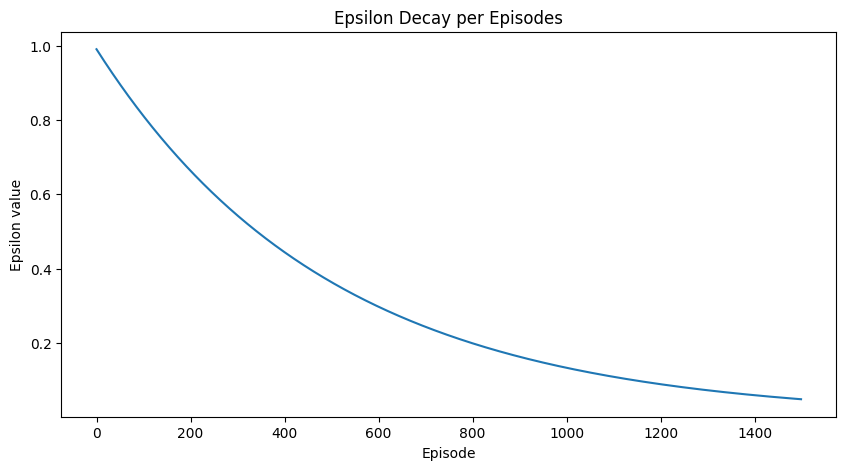

In [ ]:
def epsilon_decay_plot(sarsa_epsilon_list):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))
    plt.plot(sarsa_epsilon_list)
    plt.xlabel("Episode")
    plt.ylabel("Epsilon value")
    plt.title("Epsilon Decay per Episodes")
    plt.show()

epsilon_decay_plot(q_learning_epsilon_list)